# Phase 1b — Model Tuning

## Apa itu tuning dan kenapa perlu?

Di Phase 1a, kita sudah bikin model yang lebih baik dengan 10 fitur (MAPE 2.39%).
Tapi kita belum pernah tanya: **apakah konfigurasi model kita sudah optimal?**

Model LSTM punya banyak 'tombol' yang bisa diputar:
- Berapa hari ke belakang yang dilihat? (sequence length)
- Seberapa 'besar' otak modelnya? (LSTM units)
- Seberapa keras Dropout-nya? (dropout rate)

Di Phase 1a, kita pakai:
- Sequence length: **60 hari** (warisan dari kode lama)
- LSTM units: **128 → 64** (warisan dari kode lama)
- Dropout: **0.2** (tebakan awal)

Kita belum tahu apakah itu yang terbaik. Mungkin 30 hari lebih bagus? Mungkin 90 hari?
Mungkin model yang lebih kecil justru lebih akurat?

**Tuning = coba berbagai kombinasi secara sistematis, ukur hasilnya, pilih yang terbaik.**

## Yang akan kita eksperimen

| Parameter | Nilai yang dicoba | Penjelasan |
|-----------|------------------|------------|
| Sequence length | 30, 60, 90 hari | Berapa hari ke belakang yang dilihat model |
| Arsitektur LSTM | Small, Medium, Large | Ukuran 'otak' model |
| Dropout rate | 0.1, 0.2, 0.3 | Seberapa agresif mencegah overfitting |

Total kombinasi: 3 × 3 × 3 = **27 konfigurasi**.
Kita tidak akan coba semuanya manual — kita tulis kode yang otomatis mencoba dan mencatat hasilnya.



---
## Bagian 1 — Setup: Import dan download data

Sama persis dengan Phase 1a — kita download AAPL dari 2020 sampai hari ini.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import ta
import yfinance as yf
import joblib, json

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# Seed supaya hasil bisa direproduksi
tf.random.set_seed(42)
np.random.seed(42)

# Download data — sama seperti Phase 1a
start = datetime(2020, 1, 1)
end   = datetime.today()

pred_df = yf.download('AAPL', start=start, end=end, auto_adjust=False)

print(f'Data AAPL berhasil didownload.')
print(f'Periode: {pred_df.index[0].date()} sampai {pred_df.index[-1].date()}')
print(f'Jumlah hari trading: {len(pred_df)}')

[*********************100%***********************]  1 of 1 completed

Data AAPL berhasil didownload.
Periode: 2020-01-02 sampai 2026-05-15
Jumlah hari trading: 1601


---
## Bagian 2 — Feature engineering

Sama persis dengan Phase 1a — kita hitung semua 10 indikator.
Kita taruh di satu cell supaya rapi.

In [2]:
# Susun DataFrame dengan kolom yang kita butuhkan
aapl = pd.DataFrame()
aapl['Close']  = pred_df['Close']['AAPL']
aapl['High']   = pred_df['High']['AAPL']
aapl['Low']    = pred_df['Low']['AAPL']
aapl['Open']   = pred_df['Open']['AAPL']
aapl['Volume'] = pred_df['Volume']['AAPL']

# Hitung semua indikator (sama persis dengan Phase 1a)
aapl['RSI'] = ta.momentum.RSIIndicator(aapl['Close'], window=14).rsi()

macd_obj = ta.trend.MACD(aapl['Close'], window_fast=12, window_slow=26, window_sign=9)
aapl['MACD']        = macd_obj.macd()
aapl['MACD_Signal'] = macd_obj.macd_signal()
aapl['MACD_Hist']   = macd_obj.macd_diff()

bb_obj = ta.volatility.BollingerBands(aapl['Close'], window=20, window_dev=2)
aapl['BB_Upper']  = bb_obj.bollinger_hband()
aapl['BB_Middle'] = bb_obj.bollinger_mavg()
aapl['BB_Lower']  = bb_obj.bollinger_lband()
aapl['BB_Width']  = (aapl['BB_Upper'] - aapl['BB_Lower']) / aapl['BB_Middle']

aapl['SMA_20'] = ta.trend.SMAIndicator(aapl['Close'], window=20).sma_indicator()
aapl['SMA_50'] = ta.trend.SMAIndicator(aapl['Close'], window=50).sma_indicator()

aapl['Volume_Ratio'] = aapl['Volume'] / aapl['Volume'].rolling(20).mean()
aapl['Daily_Return'] = aapl['Close'].pct_change()

aapl.dropna(inplace=True)

FEATURES = [
    'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal',
    'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return'
]

print(f'Feature engineering selesai.')
print(f'Jumlah hari data: {len(aapl)}')
print(f'Jumlah fitur    : {len(FEATURES)}')

Feature engineering selesai.
Jumlah hari data: 1552
Jumlah fitur    : 10


---
## Bagian 3 — Definisi konfigurasi yang akan dicoba

Di sini kita definisikan semua 'tombol' yang mau kita eksperimen.

### Penjelasan setiap parameter:

**Sequence length** — berapa hari ke belakang yang dilihat model saat membuat prediksi.
- `30` hari = model hanya lihat 1.5 bulan terakhir → lebih responsif tapi kurang konteks
- `60` hari = model lihat 3 bulan terakhir → yang kita pakai di Phase 1a
- `90` hari = model lihat 4.5 bulan terakhir → lebih banyak konteks tapi lebih lambat belajar

**Arsitektur LSTM** — ukuran 'otak' model.
- `Small`  : LSTM(64) → LSTM(32)  → model ringan, training cepat, cocok untuk data sedikit
- `Medium` : LSTM(128) → LSTM(64) → yang kita pakai di Phase 1a
- `Large`  : LSTM(256) → LSTM(128) → lebih powerful tapi perlu lebih banyak data

**Dropout rate** — seberapa banyak neuron yang 'dimatikan' saat training.
- `0.1` = 10% dimatikan → regularisasi ringan
- `0.2` = 20% dimatikan → yang kita pakai di Phase 1a
- `0.3` = 30% dimatikan → regularisasi kuat, cocok kalau overfitting parah

In [3]:
# ============================================================
# KONFIGURASI YANG AKAN DICOBA
# ============================================================

# Sequence lengths yang dieksperimen
SEQUENCE_LENGTHS = [30, 60, 90]

# Arsitektur LSTM: (units layer 1, units layer 2)
ARCHITECTURES = {
    'Small' : (64, 32),
    'Medium': (128, 64),   # ini yang kita pakai di Phase 1a
    'Large' : (256, 128),
}

# Dropout rates yang dieksperimen
DROPOUT_RATES = [0.1, 0.2, 0.3]

# Split data: 95% training, 5% test — sama seperti Phase 1a
TRAIN_SPLIT = 0.95

# ============================================================
# BASELINE dari Phase 1a (untuk perbandingan)
# ============================================================
BASELINE_MAPE = 2.3910  # MAPE terbaik kamu di Phase 1a
BASELINE_RMSE = 8.0411

print('Konfigurasi yang akan dicoba:')
print(f'  Sequence lengths : {SEQUENCE_LENGTHS}')
print(f'  Arsitektur       : {list(ARCHITECTURES.keys())}')
print(f'  Dropout rates    : {DROPOUT_RATES}')
print(f'  Total kombinasi  : {len(SEQUENCE_LENGTHS)} × {len(ARCHITECTURES)} × {len(DROPOUT_RATES)} = {len(SEQUENCE_LENGTHS)*len(ARCHITECTURES)*len(DROPOUT_RATES)}')
print(f'\nBaseline Phase 1a : MAPE={BASELINE_MAPE}%, RMSE=${BASELINE_RMSE}')
print('\nTarget: MAPE di bawah 2.39%')

Konfigurasi yang akan dicoba:
  Sequence lengths : [30, 60, 90]
  Arsitektur       : ['Small', 'Medium', 'Large']
  Dropout rates    : [0.1, 0.2, 0.3]
  Total kombinasi  : 3 × 3 × 3 = 27

Baseline Phase 1a : MAPE=2.391%, RMSE=$8.0411

Target: MAPE di bawah 2.39%


---
## Bagian 4 — Helper functions

Kita bungkus semua langkah (preprocessing, build model, training, evaluasi) ke dalam fungsi.
Kenapa? Supaya kita bisa memanggil ulang dengan parameter berbeda tanpa copy-paste kode.

Analogi: daripada masak mie setiap kali dari awal, kita bikin resep yang bisa dipakai berulang
dengan bahan yang berbeda-beda.

In [4]:
def prepare_data(df, features, sequence_length, train_split=0.95):
    """
    Preprocessing data: scaling + buat sequences.
    Sama persis dengan Phase 1a, tapi sekarang jadi fungsi yang bisa dipanggil ulang.
    
    Return: x_train, y_train, x_test, y_test_raw, scaler, scaler_close, training_data_len
    """
    data = df[features].values
    close_col_idx = features.index('Close')
    training_data_len = int(np.ceil(len(data) * train_split))

    train_data = data[:training_data_len]
    test_data  = data[training_data_len:]

    # Fit scaler HANYA di training data (mencegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    test_scaled  = scaler.transform(test_data)

    # Scaler khusus untuk Close
    scaler_close = MinMaxScaler(feature_range=(0, 1))
    scaler_close.fit(train_data[:, close_col_idx].reshape(-1, 1))

    # Buat sequences untuk training
    x_train, y_train = [], []
    for i in range(sequence_length, len(train_scaled)):
        x_train.append(train_scaled[i - sequence_length:i, :])
        y_train.append(train_scaled[i, close_col_idx])
    x_train = np.array(x_train)
    y_train = np.array(y_train)

    # Buat sequences untuk testing
    test_data_full = np.vstack([train_scaled[-sequence_length:], test_scaled])
    x_test = []
    for i in range(sequence_length, len(test_data_full)):
        x_test.append(test_data_full[i - sequence_length:i, :])
    x_test = np.array(x_test)

    # y_test dalam harga asli (belum discale)
    y_test_raw = data[training_data_len:, close_col_idx]

    return x_train, y_train, x_test, y_test_raw, scaler, scaler_close, training_data_len


def build_model(sequence_length, n_features, lstm_units, dropout_rate):
    """
    Build model LSTM dengan konfigurasi yang diberikan.
    
    - lstm_units  : tuple, contoh (128, 64) artinya layer 1=128, layer 2=64
    - dropout_rate: float, contoh 0.2
    """
    model = Sequential([
        LSTM(lstm_units[0], return_sequences=True,
             input_shape=(sequence_length, n_features)),
        Dropout(dropout_rate),
        LSTM(lstm_units[1], return_sequences=False),
        Dropout(dropout_rate),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


def evaluate_model(model, x_test, y_test_raw, scaler_close):
    """
    Prediksi dan hitung RMSE + MAPE.
    Return: predictions (harga asli), rmse, mape
    """
    predictions_scaled = model.predict(x_test, verbose=0)
    predictions = scaler_close.inverse_transform(predictions_scaled)
    y_true = y_test_raw.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    mape = np.mean(np.abs((y_true - predictions) / y_true)) * 100

    return predictions, rmse, mape


print('Helper functions siap.')

Helper functions siap.


---
## Bagian 5 — Jalankan eksperimen

Di sini kita loop semua kombinasi secara otomatis.

**Estimasi waktu:** setiap konfigurasi sekitar 1-3 menit tergantung ukuran model dan komputer kamu.
Total 27 kombinasi = sekitar **30-60 menit**.

Kamu bisa tinggal sambil nunggu — hasilnya akan ditampilkan di akhir.

In [5]:
results = []  # kita simpan semua hasil di sini
best_mape = float('inf')
best_config = None
best_model = None
best_scaler = None
best_scaler_close = None

total_configs = len(SEQUENCE_LENGTHS) * len(ARCHITECTURES) * len(DROPOUT_RATES)
current = 0

print(f'Mulai eksperimen: {total_configs} konfigurasi')
print('=' * 65)

for seq_len in SEQUENCE_LENGTHS:
    for arch_name, lstm_units in ARCHITECTURES.items():
        for dropout in DROPOUT_RATES:
            current += 1
            config_name = f'seq{seq_len}_{arch_name}_drop{dropout}'

            print(f'[{current:2d}/{total_configs}] {config_name}', end=' ... ')
            start_time = time.time()

            # Step 1: Preprocessing
            x_train, y_train, x_test, y_test_raw, scaler, scaler_close, train_len = prepare_data(
                aapl, FEATURES, seq_len
            )
            n_features = x_train.shape[2]

            # Step 2: Build model
            tf.random.set_seed(42)
            np.random.seed(42)
            model = build_model(seq_len, n_features, lstm_units, dropout)

            # Step 3: Training dengan EarlyStopping
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=0  # silent supaya output tidak berantakan
            )
            history = model.fit(
                x_train, y_train,
                batch_size=32,
                epochs=50,
                validation_split=0.1,
                callbacks=[early_stop],
                verbose=0  # silent
            )

            # Step 4: Evaluasi
            predictions, rmse, mape = evaluate_model(model, x_test, y_test_raw, scaler_close)

            elapsed = time.time() - start_time
            epochs_ran = len(history.history['loss'])

            # Simpan hasil
            result = {
                'config'      : config_name,
                'seq_len'     : seq_len,
                'arch'        : arch_name,
                'lstm_units'  : lstm_units,
                'dropout'     : dropout,
                'rmse'        : round(rmse, 4),
                'mape'        : round(mape, 4),
                'epochs_ran'  : epochs_ran,
                'time_sec'    : round(elapsed, 1),
            }
            results.append(result)

            # Tandai kalau ini yang terbaik sejauh ini
            marker = ''
            if mape < best_mape:
                best_mape = mape
                best_config = result
                best_model = model
                best_scaler = scaler
                best_scaler_close = scaler_close
                marker = ' ⭐ BEST'

            print(f'MAPE={mape:.4f}%  RMSE=${rmse:.2f}  ({epochs_ran} epochs, {elapsed:.0f}s){marker}')

print('=' * 65)
print(f'\nEksperimen selesai!')
print(f'Best config: {best_config["config"]}')
print(f'Best MAPE  : {best_config["mape"]}%')
print(f'Best RMSE  : ${best_config["rmse"]}')
print(f'\nBaseline Phase 1a: MAPE={BASELINE_MAPE}%, RMSE=${BASELINE_RMSE}')
improvement = BASELINE_MAPE - best_config['mape']
if improvement > 0:
    print(f'✅ Improvement: MAPE turun {improvement:.4f}% dari baseline!')
else:
    print(f'⚠️  Baseline masih lebih baik. Coba lihat tabel di bawah untuk insight.')

Mulai eksperimen: 27 konfigurasi
[ 1/27] seq30_Small_drop0.1 ... MAPE=3.1064%  RMSE=$10.32  (13 epochs, 26s) ⭐ BEST
[ 2/27] seq30_Small_drop0.2 ... MAPE=2.9650%  RMSE=$10.50  (15 epochs, 28s) ⭐ BEST
[ 3/27] seq30_Small_drop0.3 ... WARNING:tensorflow:5 out of the last 7 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000220B1759EA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
MAPE=4.2815%  RMSE=$14.21  (14 epochs, 29s)

---
## Bagian 6 — Analisis hasil

Setelah semua eksperimen selesai, kita lihat hasilnya secara visual.
Dari sini kita bisa jawab pertanyaan:
- Sequence length mana yang paling konsisten bagus?
- Arsitektur mana yang paling optimal?
- Dropout berapa yang paling cocok?

In [6]:
# Buat DataFrame dari semua hasil
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('mape').reset_index(drop=True)

print('TOP 10 konfigurasi terbaik (sorted by MAPE):')
print('=' * 75)
print(f'{"Rank":<5} {"Config":<35} {"MAPE":<10} {"RMSE":<12} {"Epochs":<8}')
print('-' * 75)
for i, row in results_df.head(10).iterrows():
    marker = ' ⭐' if i == 0 else ''
    print(f'{i+1:<5} {row["config"]:<35} {row["mape"]:.4f}%   ${row["rmse"]:<10.4f} {row["epochs_ran"]}{marker}')

print('=' * 75)
print(f'\nBaseline Phase 1a: MAPE={BASELINE_MAPE}%')

TOP 10 konfigurasi terbaik (sorted by MAPE):
Rank  Config                              MAPE       RMSE         Epochs  
---------------------------------------------------------------------------
1     seq90_Medium_drop0.1                1.3418%   $4.6048     50 ⭐
2     seq30_Medium_drop0.1                1.4087%   $4.8710     41
3     seq90_Small_drop0.1                 1.5091%   $5.0305     50
4     seq90_Large_drop0.1                 1.5122%   $5.0140     45
5     seq60_Large_drop0.3                 1.5514%   $5.1666     50
6     seq90_Large_drop0.3                 1.6816%   $5.7260     42
7     seq30_Large_drop0.1                 1.6897%   $5.6155     38
8     seq90_Large_drop0.2                 1.7221%   $5.7753     41
9     seq90_Medium_drop0.2                1.7675%   $5.7791     50
10    seq60_Large_drop0.1                 1.7727%   $5.9303     28

Baseline Phase 1a: MAPE=2.391%


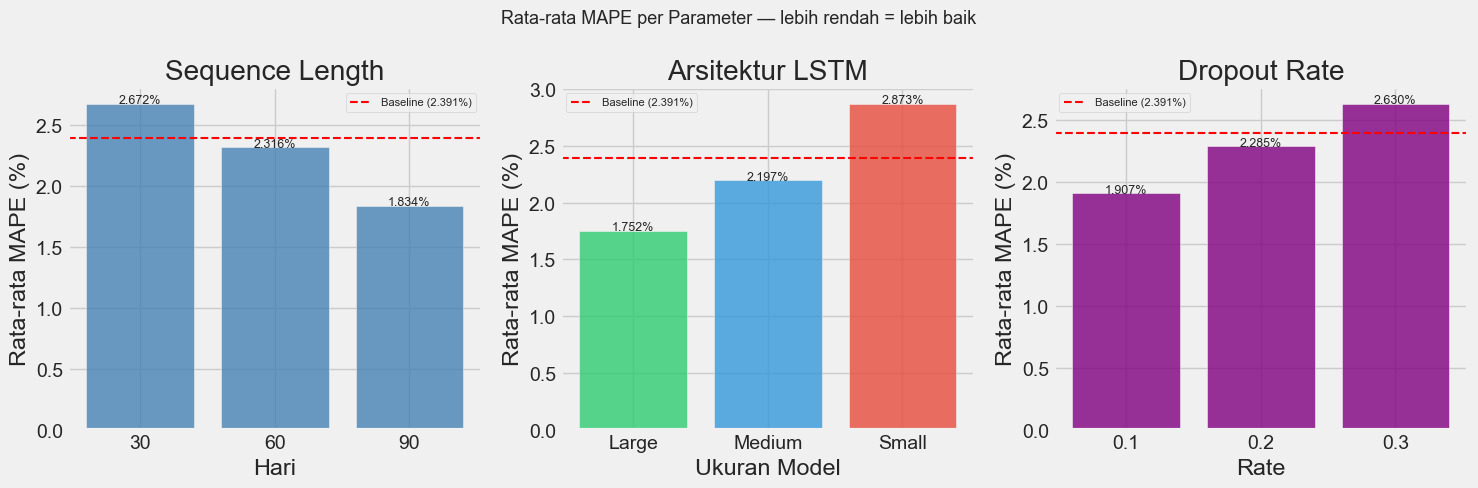


📊 INSIGHT DARI GRAFIK:
  Best sequence length : 90 hari (MAPE rata-rata 1.834%)
  Best arsitektur      : Large (MAPE rata-rata 1.752%)
  Best dropout rate    : 0.1 (MAPE rata-rata 1.907%)


In [7]:
# Visualisasi: rata-rata MAPE per parameter
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Rata-rata MAPE per Parameter — lebih rendah = lebih baik', fontsize=13)

# Plot 1: MAPE vs Sequence Length
# Dari sini kita tahu: apakah 30, 60, atau 90 hari yang paling bagus secara rata-rata
seq_avg = results_df.groupby('seq_len')['mape'].mean()
axes[0].bar([str(x) for x in seq_avg.index], seq_avg.values, color='steelblue', alpha=0.8)
axes[0].axhline(y=BASELINE_MAPE, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({BASELINE_MAPE}%)')
axes[0].set_title('Sequence Length')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Rata-rata MAPE (%)')
axes[0].legend(fontsize=8)
for i, (x, v) in enumerate(zip(seq_avg.index, seq_avg.values)):
    axes[0].text(i, v + 0.005, f'{v:.3f}%', ha='center', fontsize=9)

# Plot 2: MAPE vs Arsitektur
arch_avg = results_df.groupby('arch')['mape'].mean()
colors = ['#2ecc71', '#3498db', '#e74c3c']  # green, blue, red = small, medium, large
axes[1].bar(arch_avg.index, arch_avg.values, color=colors, alpha=0.8)
axes[1].axhline(y=BASELINE_MAPE, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({BASELINE_MAPE}%)')
axes[1].set_title('Arsitektur LSTM')
axes[1].set_xlabel('Ukuran Model')
axes[1].set_ylabel('Rata-rata MAPE (%)')
axes[1].legend(fontsize=8)
for i, (x, v) in enumerate(zip(arch_avg.index, arch_avg.values)):
    axes[1].text(i, v + 0.005, f'{v:.3f}%', ha='center', fontsize=9)

# Plot 3: MAPE vs Dropout
drop_avg = results_df.groupby('dropout')['mape'].mean()
axes[2].bar([str(x) for x in drop_avg.index], drop_avg.values, color='purple', alpha=0.8)
axes[2].axhline(y=BASELINE_MAPE, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({BASELINE_MAPE}%)')
axes[2].set_title('Dropout Rate')
axes[2].set_xlabel('Rate')
axes[2].set_ylabel('Rata-rata MAPE (%)')
axes[2].legend(fontsize=8)
for i, (x, v) in enumerate(zip(drop_avg.index, drop_avg.values)):
    axes[2].text(i, v + 0.005, f'{v:.3f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Insight otomatis
print('\n📊 INSIGHT DARI GRAFIK:')
print(f'  Best sequence length : {seq_avg.idxmin()} hari (MAPE rata-rata {seq_avg.min():.3f}%)')
print(f'  Best arsitektur      : {arch_avg.idxmin()} (MAPE rata-rata {arch_avg.min():.3f}%)')
print(f'  Best dropout rate    : {drop_avg.idxmin()} (MAPE rata-rata {drop_avg.min():.3f}%)')

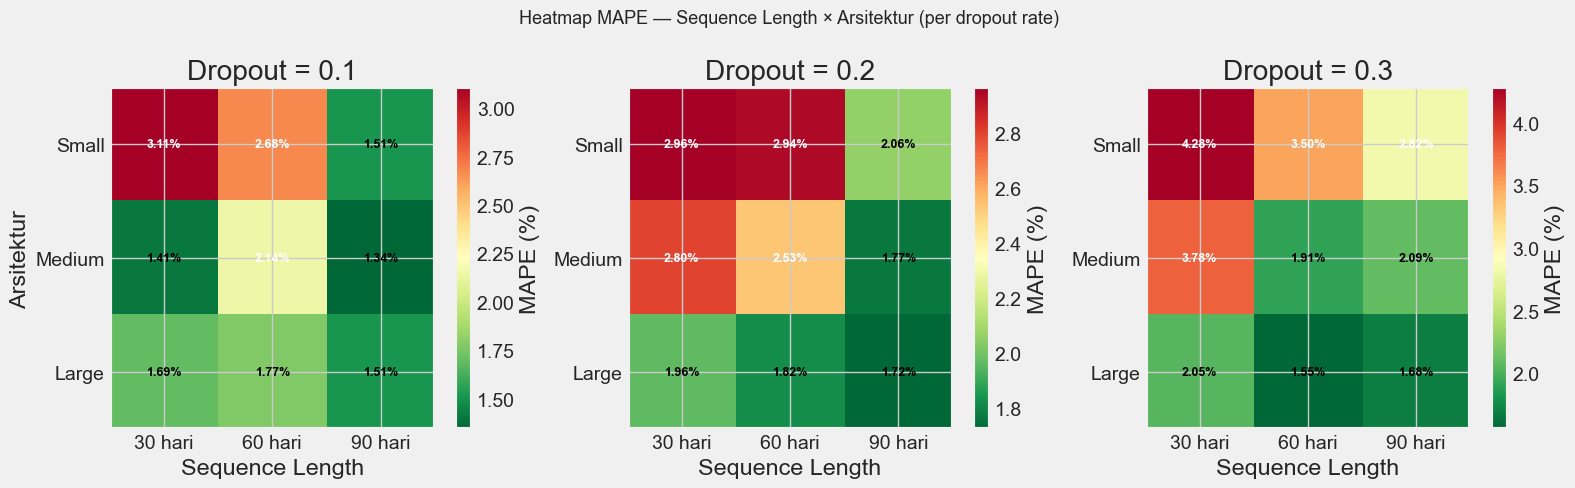

In [8]:
# Heatmap: MAPE per kombinasi sequence length × arsitektur
# Warna lebih gelap = MAPE lebih rendah = lebih baik

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Heatmap MAPE — Sequence Length × Arsitektur (per dropout rate)', fontsize=13)

for idx, dropout in enumerate(DROPOUT_RATES):
    subset = results_df[results_df['dropout'] == dropout]
    pivot = subset.pivot(index='arch', columns='seq_len', values='mape')

    # Urutkan baris
    arch_order = ['Small', 'Medium', 'Large']
    pivot = pivot.reindex(arch_order)

    im = axes[idx].imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
    axes[idx].set_xticks(range(len(pivot.columns)))
    axes[idx].set_xticklabels([f'{c} hari' for c in pivot.columns])
    axes[idx].set_yticks(range(len(pivot.index)))
    axes[idx].set_yticklabels(pivot.index)
    axes[idx].set_title(f'Dropout = {dropout}')
    axes[idx].set_xlabel('Sequence Length')
    if idx == 0:
        axes[idx].set_ylabel('Arsitektur')

    # Tambahkan angka di setiap cell
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            axes[idx].text(j, i, f'{val:.2f}%', ha='center', va='center',
                          fontsize=9, fontweight='bold',
                          color='white' if val > pivot.values.mean() else 'black')

    plt.colorbar(im, ax=axes[idx], label='MAPE (%)')

plt.tight_layout()
plt.show()

---
## Bagian 7 — Plot prediksi model terbaik

Setelah tahu konfigurasi terbaik, kita lihat visualisasi prediksinya.

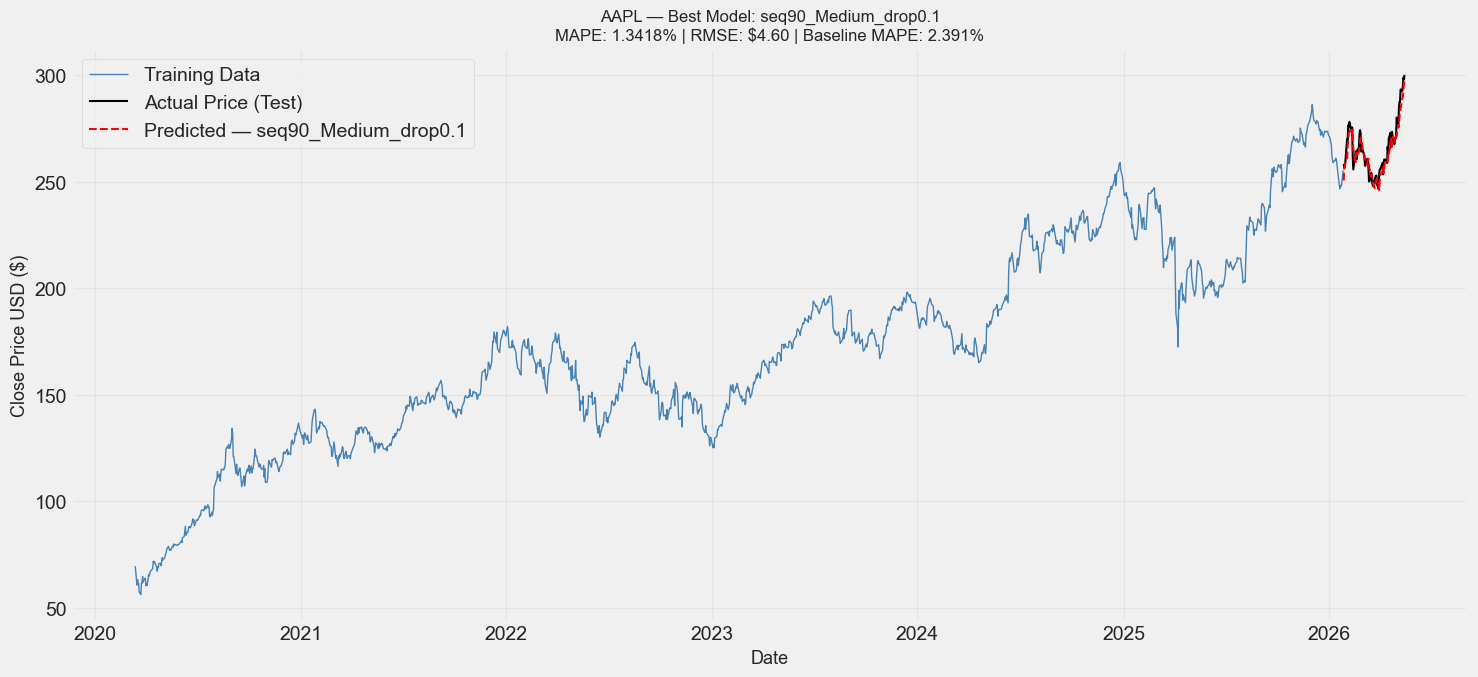

Best model config : seq90_Medium_drop0.1
MAPE              : 1.3418% (baseline: 2.391%)
RMSE              : $4.6048 (baseline: $8.0411)


In [9]:
# Ambil data untuk plot menggunakan best config
best_seq = best_config['seq_len']
x_train_b, y_train_b, x_test_b, y_test_b, scaler_b, scaler_close_b, train_len_b = prepare_data(
    aapl, FEATURES, best_seq
)

predictions_best, rmse_best, mape_best = evaluate_model(
    best_model, x_test_b, y_test_b, scaler_close_b
)

train_plot = aapl['Close'][:train_len_b]
test_dates = aapl.index[train_len_b:]
y_test_prices = y_test_b.reshape(-1, 1)

plt.figure(figsize=(15, 7))
plt.title(
    f'AAPL — Best Model: {best_config["config"]}\n'
    f'MAPE: {mape_best:.4f}% | RMSE: ${rmse_best:.2f} | '
    f'Baseline MAPE: {BASELINE_MAPE}%',
    fontsize=12
)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Close Price USD ($)', fontsize=13)

plt.plot(train_plot.index, train_plot.values, label='Training Data', color='steelblue', linewidth=1)
plt.plot(test_dates, y_test_prices, label='Actual Price (Test)', color='black', linewidth=1.5)
plt.plot(test_dates, predictions_best, label=f'Predicted — {best_config["config"]}',
         color='red', linewidth=1.5, linestyle='--')

plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best model config : {best_config["config"]}')
print(f'MAPE              : {mape_best:.4f}% (baseline: {BASELINE_MAPE}%)')
print(f'RMSE              : ${rmse_best:.4f} (baseline: ${BASELINE_RMSE})')

---
## Bagian 8 — Simpan model terbaik

Model terbaik dari tuning ini kita simpan sebagai `v3` — satu versi di atas Phase 1a (`v2`).

In [10]:
os.makedirs('../models', exist_ok=True)

# Simpan model terbaik
best_model.save('../models/AAPLstock_price_prediction_model_v3.keras')
print('Model terbaik tersimpan: ../models/AAPLstock_price_prediction_model_v3.keras')

# Simpan scaler
joblib.dump(best_scaler,       '../models/scaler_all_features_v3.pkl')
joblib.dump(best_scaler_close, '../models/scaler_close_v3.pkl')
print('Scaler tersimpan.')

# Simpan meta: konfigurasi terbaik + daftar fitur
# Ini WAJIB disimpan — kalau load model nanti, kita harus tahu
# sequence_length dan urutan fitur yang dipakai
meta_v3 = {
    'features'        : FEATURES,
    'sequence_length' : best_config['seq_len'],
    'architecture'    : best_config['arch'],
    'lstm_units'      : list(best_config['lstm_units']),
    'dropout'         : best_config['dropout'],
    'mape'            : best_config['mape'],
    'rmse'            : best_config['rmse'],
    'trained_on'      : f'2020-01-01 to {datetime.today().strftime("%Y-%m-%d")}',
}
with open('../models/model_v3_meta.json', 'w') as f:
    json.dump(meta_v3, f, indent=2)
print('Meta tersimpan: ../models/model_v3_meta.json')

# Simpan semua hasil eksperimen ke CSV untuk referensi
results_df.to_csv('../models/tuning_results.csv', index=False)
print('Semua hasil tuning tersimpan: ../models/tuning_results.csv')

print()
print('=' * 50)
print('RINGKASAN PHASE 1b')
print('=' * 50)
print(f'Model v1 (original) : MAPE 2.4546%')
print(f'Model v2 (Phase 1a) : MAPE {BASELINE_MAPE}%')
print(f'Model v3 (Phase 1b) : MAPE {best_config["mape"]}%')
print(f'Konfigurasi terbaik : {best_config["config"]}')
print('=' * 50)
print('\nNext step: Phase 1c — replikasi ke BBCA dan BBRI')

Model terbaik tersimpan: ../models/AAPLstock_price_prediction_model_v3.keras
Scaler tersimpan.
Meta tersimpan: ../models/model_v3_meta.json
Semua hasil tuning tersimpan: ../models/tuning_results.csv

RINGKASAN PHASE 1b
Model v1 (original) : MAPE 2.4546%
Model v2 (Phase 1a) : MAPE 2.391%
Model v3 (Phase 1b) : MAPE 1.3418%
Konfigurasi terbaik : seq90_Medium_drop0.1

Next step: Phase 1c — replikasi ke BBCA dan BBRI
